In [ ]:
# Uncomment if needed
# !pip install importlib
# !pip install importlib-metadata

In [ ]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "tqdm", "matplotlib", "scikit-learn", "seaborn", "kagglehub", "ipywidgets"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0+cu128). Checking for upgrade...
torchvision is installed (version 0.25.0+cu128). Checking for upgrade...
torchaudio is installed (version 2.10.0+cu128). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.0). Checking for upgrade...
scikit-learn is installed (version 1.6.1). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 0.3.13). Checking for upgrade...
ipywidgets is installed (version 7.7.1). Checking for upgrade...
####################################################################


In [ ]:
# Handle imports
import os
import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import time
import kagglehub
import utils
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [ ]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name="resnet"
prev_stage=None

path_final_models , path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Mounted at /content/drive
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models/resnet_no_aug
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/resnet_no_aug
Plots: /content/drive/MyDrive/plots/resnet_no_aug
OCT Models: /content/drive/MyDrive/oct_models/resnet_no_aug


In [ ]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cuda
####################################################################


In [ ]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [ ]:
import shutil
import os

# Define the High-Speed Path
KAGGE_CACHE = DATA_PATH
RAM_DISK_PATH = '/dev/shm/oct2017'

# Move it to RAM
if not os.path.exists(RAM_DISK_PATH):
    print("Moving dataset to RAM disk for maximum speed...")
    shutil.copytree(KAGGE_CACHE, RAM_DISK_PATH)
    print("Done!")

# Update DATA_PATH variable
DATA_PATH = RAM_DISK_PATH

Moving dataset to RAM disk for maximum speed...
Done!


In [ ]:
torch.set_float32_matmul_precision('high')

In [ ]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [ ]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [ ]:
# Image transformation
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Pass Transform Into Dataset
train_dataset = utils.OCTDataset(train_df, transform=transform)
val_dataset = utils.OCTDataset(val_df, transform=transform)
test_dataset = utils.OCTDataset(test_df, transform=transform)

In [ ]:
# Define y_train variable based on labels
y_train = torch.tensor(train_df["label_encoded"].values)

# In order to define the weighted cross entropy loss we need the weights
class_counts = torch.bincount(y_train.cpu()) # Exw upo8esei pws exoume orisei to y_train
num_classes = 4
total_samples = len(y_train)
class_weights = total_samples / (num_classes * class_counts)

class_weights = class_weights.to(device) # Move weights to same device

# Import resnet18 with default weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
# Replace fc layer for 4 classes
model.fc = nn.Linear(model.fc.in_features, 4)
# Move model to device
model = model.to(device)
print("####################################################################")
print("Model created successfully.")
print("####################################################################")
print("The model creeated is:")
print(model)
print("####################################################################")
print("Check number of total parameters in the model:", sum(p.numel() for p in model.parameters()))
print("####################################################################")

# Define Cross Entropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

####################################################################
Model created successfully.
####################################################################
The model creeated is:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, ke

**Comments**

Layer	Output Channels	Meaning

conv1	64	edges

layer1	64	low-level textures

layer2	128	mid-level patterns

layer3	256	structural patterns

layer4	512	semantic features

fc	4	disease classes

In [ ]:
# Use a fraction of data for testing the code
print("####################################################################")
print("What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]")
FRACTION = float(input("Please give a number between 0 - 1: "))
print("Using FRACTION =", FRACTION,"[", FRACTION*100,"% of all data]")
print("####################################################################")

# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

fraction_train_dataset = utils.get_subset(train_dataset, FRACTION)
fraction_val_dataset   = utils.get_subset(val_dataset, FRACTION)
fraction_test_dataset  = utils.get_subset(test_dataset, FRACTION)

train_loader = DataLoader(fraction_train_dataset, batch_size=BATCH_SIZE, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=True, pin_memory=True)
val_loader   = DataLoader(fraction_val_dataset, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(fraction_test_dataset, batch_size=BATCH_SIZE)

sum_fraction_data = (len(fraction_train_dataset)+len(fraction_val_dataset)+len(fraction_test_dataset))

print("####################################################################")
print("Fraction of train data:", len(fraction_train_dataset),"images [",len(fraction_train_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of val data:", len(fraction_val_dataset),"images [",len(fraction_val_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of test data:", len(fraction_test_dataset),"images [",len(fraction_test_dataset)/(sum_total_data)*100,"% ]")
print("####################################################################")
print("Data that will be used are:", sum_fraction_data,"images [",sum_fraction_data/(sum_total_data)*100,"% ]")
print("####################################################################")

####################################################################
What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]
Please give a number between 0 - 1: 1
Using FRACTION = 1.0 [ 100.0 % of all data]
####################################################################
####################################################################
Enter batch size (e.g., 32, 64, 128): 512
Using batch size: 512
####################################################################
####################################################################
Fraction of train data: 50580 images [ 60.12124093664567 % ]
Fraction of val data: 16851 images [ 20.029715915844527 % ]
Fraction of test data: 16699 images [ 19.849043147509807 % ]
####################################################################
Data that will be used are: 84130 images [ 100.0 % ]
####################################################################


In [ ]:
stages = ['fc','layer4', 'layer3', 'layer2', 'layer1', None]
print("########################################################################################")
print("The defined stages for training oct-classification model are:")
print(stages)
print("#######################################################################################")

########################################################################################
The defined stages for training oct-classification model are:
['fc', 'layer4', 'layer3', 'layer2', 'layer1', None]
#######################################################################################


In [ ]:
print("#################################################################################")
while True:
    try:
        num_epochs = int(input("Please give number of epochs to run at each stage: "))
        if num_epochs <= 0:
            print("Please enter a positive integer.")
            continue
        break
    except ValueError:
        print("Invalid input, please enter a number.")
print("The defined number of epochs is", num_epochs)
print("#################################################################################")

#################################################################################
Please give number of epochs to run at each stage: 15
The defined number of epochs is 15
#################################################################################


#################################################################################################################################
Please wait until training the "oct-classification model" is done.


Stage:   0%|          | 0/6 [00:00<?, ?stage/s]

[INFO] Best model for fc already exists. Skipping to next stage.
Model type: ResNet
Layer parameters that are NOT frozen at this stage are:
layer4.0.conv1.weight True
layer4.0.bn1.weight True
layer4.0.bn1.bias True
layer4.0.conv2.weight True
layer4.0.bn2.weight True
layer4.0.bn2.bias True
layer4.0.downsample.0.weight True
layer4.0.downsample.1.weight True
layer4.0.downsample.1.bias True
layer4.1.conv1.weight True
layer4.1.bn1.weight True
layer4.1.bn1.bias True
layer4.1.conv2.weight True
layer4.1.bn2.weight True
layer4.1.bn2.bias True
fc.weight True
fc.bias True

Frozen layers at this stage are: ['layer1', 'layer2', 'layer3']
Loading best model from previous stage: fc for stage layer4
Starting stage 'layer4' from epoch 1 with LR = 1.00e-04
---------------------------------------------------------------------------------------------------------------------------------

*************************************************  Running epoch: 1 out of 15  *****************************************

Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer4_checkpoint_epoch_0.pt
Epoch 1 [layer4]: Train Loss = 0.3393 | Train F1 = 0.8480 | Val Loss = 0.2636 | Val F1 = 0.8987 | LR = 9.89e-05 | Time = 113.09s

*************************************************  Running epoch: 2 out of 15  ****************************************************


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer4_checkpoint_epoch_7.pt
Epoch 8 [layer4]: Train Loss = 0.0093 | Train F1 = 0.9970 | Val Loss = 0.3406 | Val F1 = 0.9176 | LR = 4.53e-05 | Time = 113.21s

*************************************************  Running epoch: 9 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer4_checkpoint_epoch_8.pt
Epoch 9 [layer4]: Train Loss = 0.0090 | Train F1 = 0.9968 | Val Loss = 0.3597 | Val F1 = 0.9173 | LR = 3.52e-05 | Time = 112.40s

*************************************************  Running epoch: 10 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer4_checkpoint_epoch_9.pt
Epoch 10 [layer4]: Train Loss = 0.0080 | Train F1 = 0.9971 | Val Loss = 0.3356 | Val F1 = 0.9185 | LR = 2.58e-05 | Time = 112.17s
Early stopping triggered.
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/resnet_aug/resnet18_layer4_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 10

The loss and training curves at stage layer4 are:

Plot saved to: /content/drive/MyDrive/plots/resnet_aug/stage_layer4_training_not_aug.png


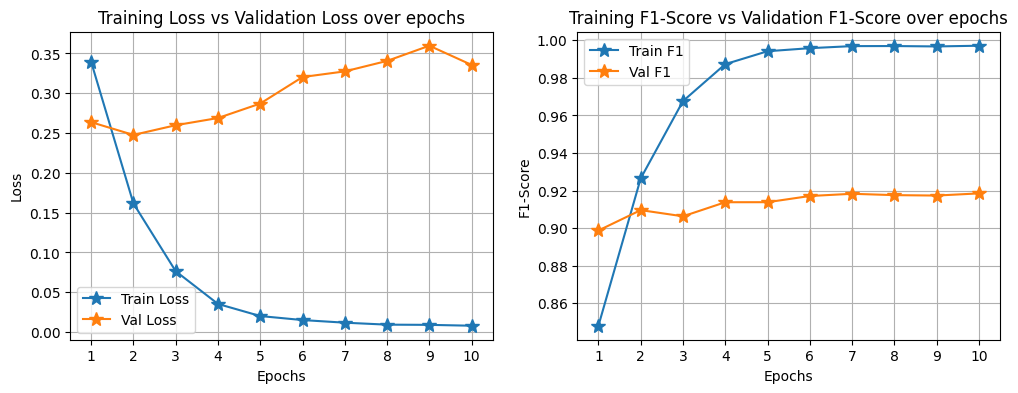

Stage:  33%|███▎      | 2/6 [18:54<37:49, 567.39s/stage]


Training of stage "layer4" completed in 18.91 minutes.

Model type: ResNet
Layer parameters that are NOT frozen at this stage are:
layer3.0.conv1.weight True
layer3.0.bn1.weight True
layer3.0.bn1.bias True
layer3.0.conv2.weight True
layer3.0.bn2.weight True
layer3.0.bn2.bias True
layer3.0.downsample.0.weight True
layer3.0.downsample.1.weight True
layer3.0.downsample.1.bias True
layer3.1.conv1.weight True
layer3.1.bn1.weight True
layer3.1.bn1.bias True
layer3.1.conv2.weight True
layer3.1.bn2.weight True
layer3.1.bn2.bias True
layer4.0.conv1.weight True
layer4.0.bn1.weight True
layer4.0.bn1.bias True
layer4.0.conv2.weight True
layer4.0.bn2.weight True
layer4.0.bn2.bias True
layer4.0.downsample.0.weight True
layer4.0.downsample.1.weight True
layer4.0.downsample.1.bias True
layer4.1.conv1.weight True
layer4.1.bn1.weight True
layer4.1.bn1.bias True
layer4.1.conv2.weight True
layer4.1.bn2.weight True
layer4.1.bn2.bias True
fc.weight True
fc.bias True

Frozen layers at this stage are: ['laye

Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.67s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer3_checkpoint_epoch_0.pt
Epoch 1 [layer3]: Train Loss = 0.0365 | Train F1 = 0.9862 | Val Loss = 0.3236 | Val F1 = 0.9084 | LR = 9.89e-05 | Time = 113.46s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer3_checkpoint_epoch_5.pt
Epoch 6 [layer3]: Train Loss = 0.0053 | Train F1 = 0.9972 | Val Loss = 0.3337 | Val F1 = 0.9272 | LR = 6.58e-05 | Time = 112.82s

*************************************************  Running epoch: 7 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.69s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer3_checkpoint_epoch_6.pt
Epoch 7 [layer3]: Train Loss = 0.0046 | Train F1 = 0.9973 | Val Loss = 0.3471 | Val F1 = 0.9279 | LR = 5.57e-05 | Time = 115.29s

*************************************************  Running epoch: 8 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer3_checkpoint_epoch_7.pt
Epoch 8 [layer3]: Train Loss = 0.0042 | Train F1 = 0.9973 | Val Loss = 0.3485 | Val F1 = 0.9278 | LR = 4.53e-05 | Time = 113.92s
Early stopping triggered.
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/resnet_aug/resnet18_layer3_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 8

The loss and training curves at stage layer3 are:

Plot saved to: /content/drive/MyDrive/plots/resnet_aug/stage_layer3_training_not_aug.png


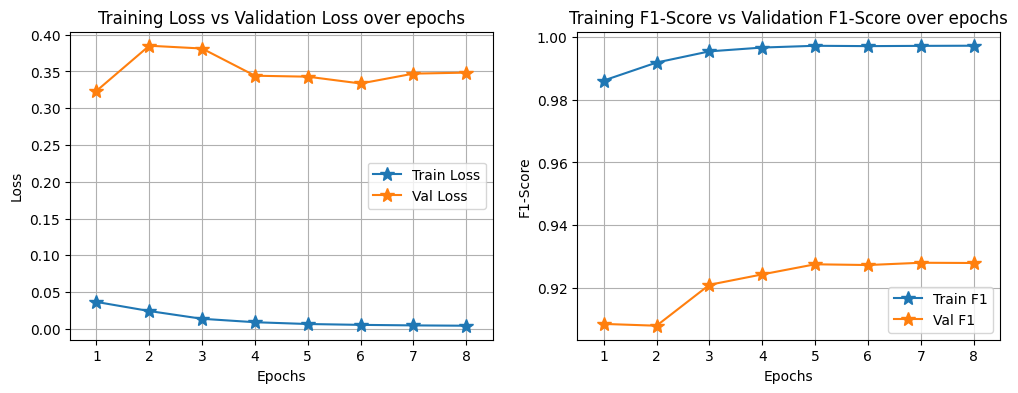

Stage:  50%|█████     | 3/6 [34:04<35:29, 709.85s/stage]


Training of stage "layer3" completed in 15.15 minutes.

Model type: ResNet
Layer parameters that are NOT frozen at this stage are:
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer3.0.conv1.weight True
layer3.0.bn1.weight True
layer3.0.bn1.bias True
layer3.0.conv2.weight True
layer3.0.bn2.weight True
layer3.0.bn2.bias True
layer3.0.downsample.0.weight True
layer3.0.downsample.1.weight True
layer3.0.downsample.1.bias True
layer3.1.conv1.weight True
layer3.1.bn1.weight True
layer3.1.bn1.bias True
layer3.1.conv2.weight True
layer3.1.bn2.weight True
layer3.1.bn2.bias True
layer4.0.conv1.weight True
layer4.0.bn1.weight True
layer4.0.bn1.bia

Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer2_checkpoint_epoch_0.pt
Epoch 1 [layer2]: Train Loss = 0.0209 | Train F1 = 0.9910 | Val Loss = 0.3410 | Val F1 = 0.9186 | LR = 9.89e-05 | Time = 113.49s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer2_checkpoint_epoch_7.pt
Epoch 8 [layer2]: Train Loss = 0.0033 | Train F1 = 0.9973 | Val Loss = 0.3525 | Val F1 = 0.9336 | LR = 4.53e-05 | Time = 114.50s

*************************************************  Running epoch: 9 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.69s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer2_checkpoint_epoch_8.pt
Epoch 9 [layer2]: Train Loss = 0.0033 | Train F1 = 0.9973 | Val Loss = 0.3651 | Val F1 = 0.9331 | LR = 3.52e-05 | Time = 113.64s

*************************************************  Running epoch: 10 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer2_checkpoint_epoch_9.pt
Epoch 10 [layer2]: Train Loss = 0.0032 | Train F1 = 0.9974 | Val Loss = 0.3600 | Val F1 = 0.9338 | LR = 2.58e-05 | Time = 113.26s
Early stopping triggered.
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/resnet_aug/resnet18_layer2_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 10

The loss and training curves at stage layer2 are:

Plot saved to: /content/drive/MyDrive/plots/resnet_aug/stage_layer2_training_not_aug.png


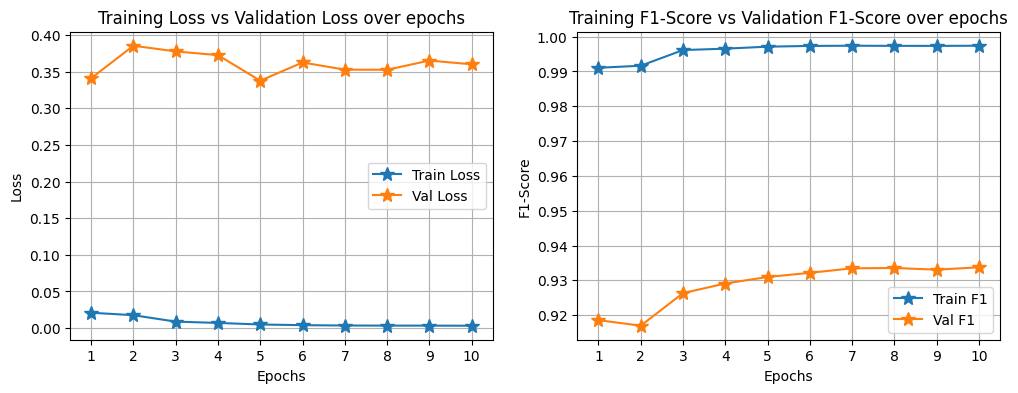

Stage:  67%|██████▋   | 4/6 [53:08<29:04, 872.03s/stage]


Training of stage "layer2" completed in 19.07 minutes.

Model type: ResNet
Layer parameters that are NOT frozen at this stage are:
layer1.0.conv1.weight True
layer1.0.bn1.weight True
layer1.0.bn1.bias True
layer1.0.conv2.weight True
layer1.0.bn2.weight True
layer1.0.bn2.bias True
layer1.1.conv1.weight True
layer1.1.bn1.weight True
layer1.1.bn1.bias True
layer1.1.conv2.weight True
layer1.1.bn2.weight True
layer1.1.bn2.bias True
layer2.0.conv1.weight True
layer2.0.bn1.weight True
layer2.0.bn1.bias True
layer2.0.conv2.weight True
layer2.0.bn2.weight True
layer2.0.bn2.bias True
layer2.0.downsample.0.weight True
layer2.0.downsample.1.weight True
layer2.0.downsample.1.bias True
layer2.1.conv1.weight True
layer2.1.bn1.weight True
layer2.1.bn1.bias True
layer2.1.conv2.weight True
layer2.1.bn2.weight True
layer2.1.bn2.bias True
layer3.0.conv1.weight True
layer3.0.bn1.weight True
layer3.0.bn1.bias True
layer3.0.conv2.weight True
layer3.0.bn2.weight True
layer3.0.bn2.bias True
layer3.0.downsampl

Evaluating: 100%|██████████| 33/33 [00:56<00:00,  1.70s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer1_checkpoint_epoch_0.pt
Epoch 1 [layer1]: Train Loss = 0.0186 | Train F1 = 0.9906 | Val Loss = 0.4432 | Val F1 = 0.9127 | LR = 9.89e-05 | Time = 114.42s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.69s/batch]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer1_checkpoint_epoch_11.pt
Epoch 12 [layer1]: Train Loss = 0.0029 | Train F1 = 0.9973 | Val Loss = 0.3705 | Val F1 = 0.9398 | LR = 1.05e-05 | Time = 113.41s

*************************************************  Running epoch: 13 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer1_checkpoint_epoch_12.pt
Epoch 13 [layer1]: Train Loss = 0.0029 | Train F1 = 0.9973 | Val Loss = 0.3705 | Val F1 = 0.9394 | LR = 5.28e-06 | Time = 114.33s

*************************************************  Running epoch: 14 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:56<00:00,  1.71s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/layer1_checkpoint_epoch_13.pt
Epoch 14 [layer1]: Train Loss = 0.0028 | Train F1 = 0.9973 | Val Loss = 0.3737 | Val F1 = 0.9387 | LR = 2.08e-06 | Time = 114.87s
Early stopping triggered.
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/resnet_aug/resnet18_layer1_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 14

The loss and training curves at stage layer1 are:

Plot saved to: /content/drive/MyDrive/plots/resnet_aug/stage_layer1_training_not_aug.png


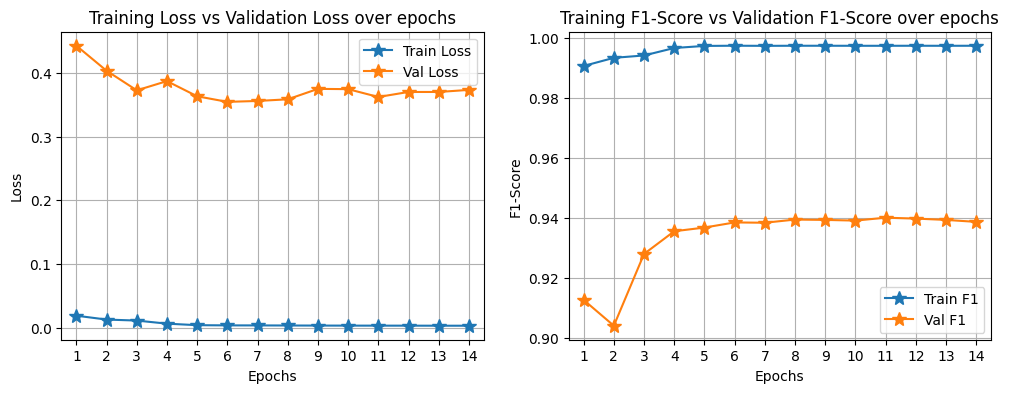

Stage:  83%|████████▎ | 5/6 [1:19:54<18:47, 1127.35s/stage]


Training of stage "layer1" completed in 26.77 minutes.

No layers are frozen, all layers are trainable.

Loading best model from previous stage: layer1 for stage None
Starting stage 'None' from epoch 1 with LR = 1.00e-04
---------------------------------------------------------------------------------------------------------------------------------

*************************************************  Running epoch: 1 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/None_checkpoint_epoch_0.pt
Epoch 1 [None]: Train Loss = 0.0146 | Train F1 = 0.9923 | Val Loss = 0.3845 | Val F1 = 0.9219 | LR = 9.89e-05 | Time = 116.08s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.69s/batch]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/None_checkpoint_epoch_6.pt
Epoch 7 [None]: Train Loss = 0.0032 | Train F1 = 0.9973 | Val Loss = 0.3321 | Val F1 = 0.9410 | LR = 5.57e-05 | Time = 113.81s

*************************************************  Running epoch: 8 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/None_checkpoint_epoch_7.pt
Epoch 8 [None]: Train Loss = 0.0030 | Train F1 = 0.9973 | Val Loss = 0.3312 | Val F1 = 0.9419 | LR = 4.53e-05 | Time = 114.69s

*************************************************  Running epoch: 9 out of 15  ****************************************************


Evaluating: 100%|██████████| 33/33 [00:55<00:00,  1.68s/batch]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/resnet_aug/None_checkpoint_epoch_8.pt
Epoch 9 [None]: Train Loss = 0.0030 | Train F1 = 0.9973 | Val Loss = 0.3344 | Val F1 = 0.9411 | LR = 3.52e-05 | Time = 113.87s
Early stopping triggered.
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/resnet_aug/resnet18_None_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 9

The loss and training curves at stage None are:

Plot saved to: /content/drive/MyDrive/plots/resnet_aug/stage_full_training_not_aug.png


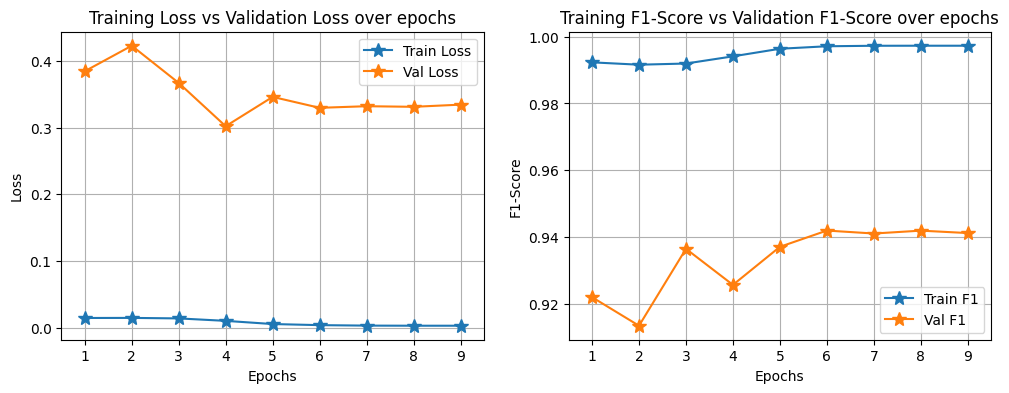

Stage: 100%|██████████| 6/6 [1:37:08<00:00, 971.48s/stage] 


Training of stage "None" completed in 17.23 minutes.

#################################################################################################################################


In [ ]:
lr = 1e-4  # initial learning rate

print("#" * 129)
print("Please wait until training the \"oct-classification model\" is done.")

prev_stage = None

for stage in tqdm(stages, desc='Stage', unit='stage', position=0, leave=True):
    # Check if stage is completed by finding if best model exists
    best_model_path = os.path.join(path_oct_models, f"resnet18_{stage}_best.pth")
    if os.path.exists(best_model_path):
        print(f"[INFO] Best model for {stage} already exists. Skipping to next stage.")
        prev_stage = stage
        continue

    early_stopping = utils.Early_Stopping()

    # Freeze layers for the stage
    utils.freeze_first_n_layers(model, stage)

    # Setup optimizer & scheduler
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    # Load checkpoint if it exists
    (model, optimizer, scheduler, start_epoch,
     train_epoch_losses, train_epoch_f1s,
     val_epoch_losses, val_epoch_f1s,
     num_epochs_checkpoint, data_fraction_checkpoint) = utils.load_latest_checkpoint(model, optimizer, scheduler, stage, path=path_hackathon_checkpoints)

    if start_epoch == 0 and prev_stage is not None:
        prev_best_model_path = os.path.join(path_oct_models, f"resnet18_{prev_stage}_best.pth")
        if os.path.exists(prev_best_model_path):
            print(f"Loading best model from previous stage: {prev_stage} for stage {stage}")
            model.load_state_dict(torch.load(prev_best_model_path, map_location=device))
        else:
            print(f"No best model found for previous stage: {prev_stage}, starting from current model weights.")

    resumed_lr = optimizer.param_groups[0]['lr']
    stage_start = time.time()
    print(f"Starting stage '{stage}' from epoch {start_epoch + 1} with LR = {resumed_lr:.2e}")
    print("-" * 129)

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        print("")
        print("*" * 49, f" Running epoch: {epoch + 1} out of {num_epochs} ", "*" * 52)

        # Train + Evaluate
        train_epoch_loss, train_epoch_f1 = utils.train_model(model, train_loader, criterion, optimizer, device)
        val_epoch_loss, val_epoch_f1 = utils.evaluate(model, val_loader, criterion, device)

        # Update LR
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Accumulate metrics
        train_epoch_losses.append(train_epoch_loss)
        train_epoch_f1s.append(train_epoch_f1)
        val_epoch_losses.append(val_epoch_loss)
        val_epoch_f1s.append(val_epoch_f1)

        # Save checkpoint
        utils.save_checkpoint(model, optimizer, scheduler, stage, epoch,
                        train_epoch_losses, train_epoch_f1s,
                        val_epoch_losses, val_epoch_f1s,
                        num_epochs=num_epochs,
                        data_fraction=FRACTION,
                        path=path_hackathon_checkpoints)

        epoch_time = time.time() - epoch_start
        print("=" * 129)
        print(
            f"Epoch {epoch + 1} [{stage}]: "
            f"Train Loss = {train_epoch_loss:.4f} | Train F1 = {train_epoch_f1:.4f} | "
            f"Val Loss = {val_epoch_loss:.4f} | Val F1 = {val_epoch_f1:.4f} | "
            f"LR = {current_lr:.2e} | Time = {epoch_time:.2f}s"
        )
        print("=" * 129)

        # Early stopping
        early_stopping(val_epoch_f1, model)
        if early_stopping.early_stop:
            model.load_state_dict(early_stopping.best_state)
            best_model = copy.deepcopy(model)
            utils.save_best_model(best_model, "resnet18", stage, path_to_models=path_oct_models)
            print("!" * 40)
            print(f"Stopping early at epoch {epoch + 1}")
            break

    # Save best model if early stop did not trigger
    if not early_stopping.early_stop:
        model.load_state_dict(early_stopping.best_state)
        best_model = copy.deepcopy(model)
        utils.save_best_model(best_model, "resnet18", stage, path_to_models=path_oct_models)

    prev_stage = stage

    # Plot curves using accumulated metrics (including resumed epochs)
    print(f"\nThe loss and training curves at stage {stage} are:\n")
    utils.loss_train_curve_plots(
        num_epochs=len(train_epoch_losses),
        train_epoch_losses=train_epoch_losses,
        train_epoch_f1s=train_epoch_f1s,
        val_epoch_losses=val_epoch_losses,
        val_epoch_f1s=val_epoch_f1s,
        save_plot=True,
        stage=stage,
        model_name='resnet18',
        augmented=False,
        path_plots=path_plots
    )

    total_stage_time = time.time() - stage_start
    print(f"\nTraining of stage \"{stage}\" completed in {total_stage_time / 60:.2f} minutes.\n")

print("#" * 129)


Extracted 66 total epochs across 6 stages.
Best models identified at global epoch indices: [12, 21, 29, 39, 53, 62]


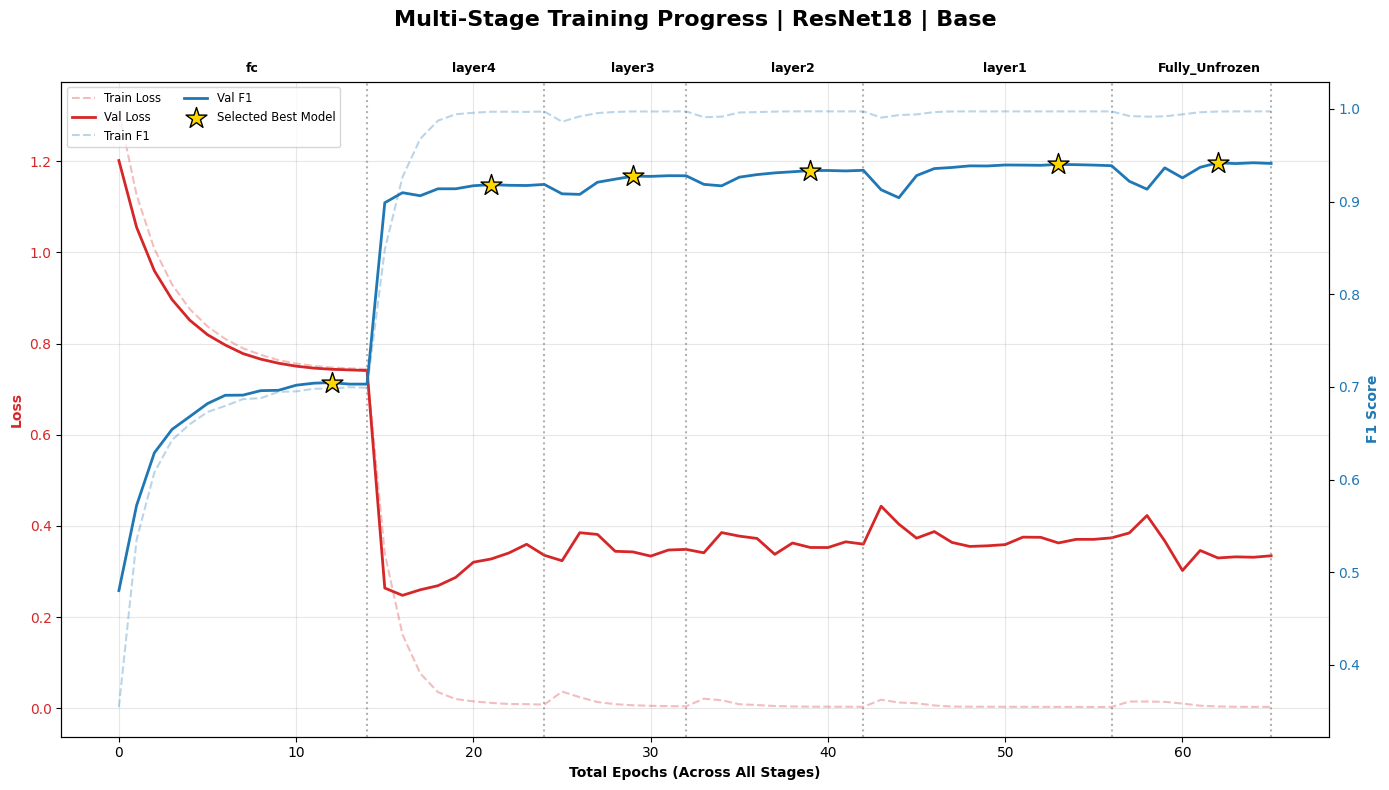

In [ ]:
# Extract all the data from checkpoints
metrics_dict = utils.extract_all_metrics(stages, path_hackathon_checkpoints, model_name="ResNet18")

# Check if data exists
if not metrics_dict['val_loss']:
    print("No metrics found. Check your stage names and checkpoint path.")
else:
    total_epochs = len(metrics_dict['val_loss'])
    print(f"Extracted {total_epochs} total epochs across {len(stages)} stages.")
    print(f"Best models identified at global epoch indices: {metrics_dict['best_indices']}")

    # Generate the visualization once for inspection
    utils.plot_multi_stage_metrics(
        metrics=metrics_dict,
        stages=stages,
        model_name='ResNet18',
        is_augmented=False
    )
plt.show()

Choose the epoch index of the final model to highlight: 16
Plot saved to: /content/drive/MyDrive/plots/resnet_no_aug


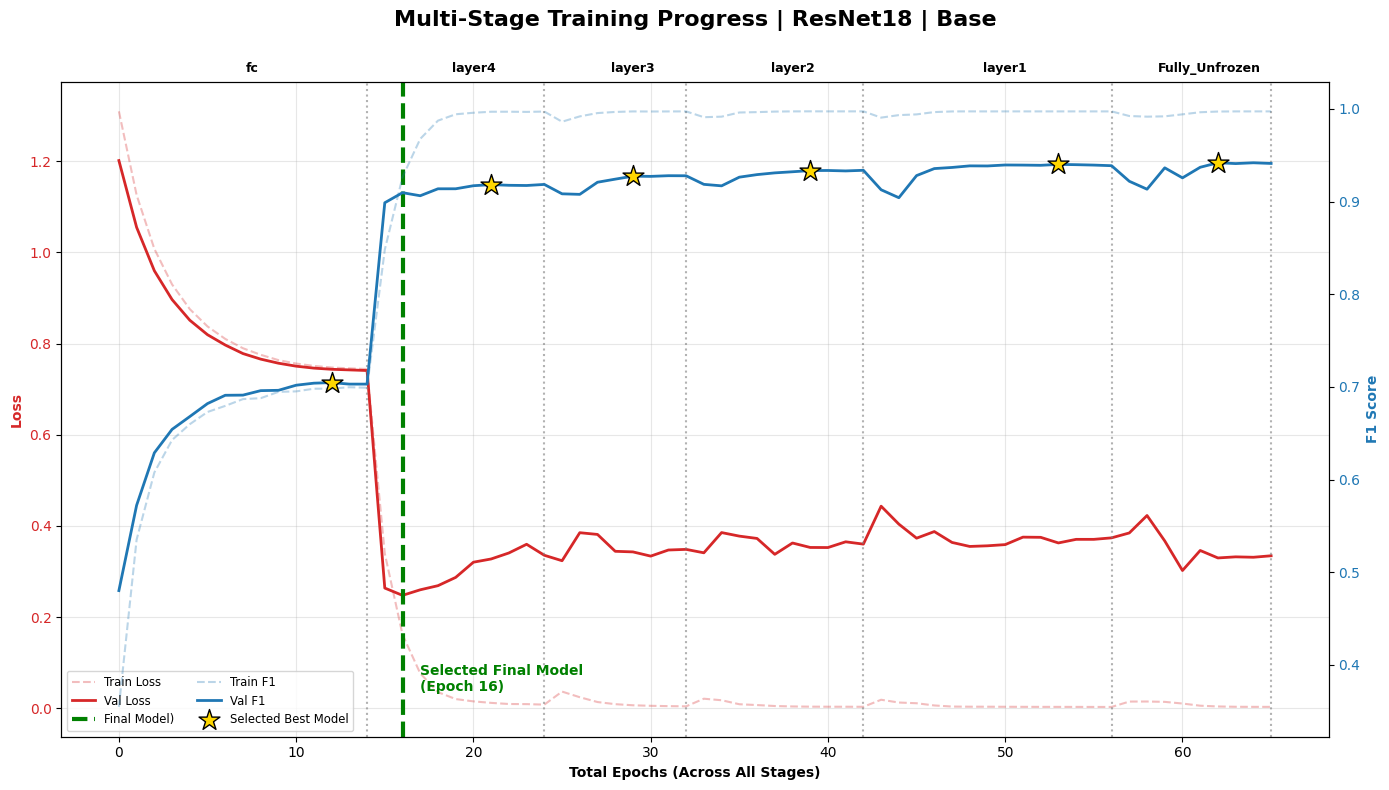

In [ ]:
#  Generate the plot again to show best model
utils.plot_multi_stage_metrics(
    metrics=metrics_dict,
    stages=stages,
    model_name='ResNet18',
    is_augmented=False
)

# Epoch 16 should be selected
target_epoch = int(input("Choose the epoch index of the final model to highlight: "))
ax1 = plt.gcf().axes[0]  # Get the Loss axis
ax2 = plt.gcf().axes[1]  # Get the F1 axis

# Draw the selection line
line_selection = ax1.axvline(x=target_epoch, color='green', linestyle='--',
                             linewidth=3, label='Final Model)')

# Add the text annotation
ax1.text(target_epoch + 1, ax1.get_ylim()[0] + 0.1, f'Selected Final Model\n(Epoch {target_epoch})',
         color='green', fontweight='bold')

# Gather all handles and labels from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Remove the old legend if it exists to prevent ghosting
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

# Create one final combined legend on ax1 or ax2
ax1.legend(h1 + h2, l1 + l2, loc='lower left', ncol=2, fontsize='small', frameon=True)

# Save and show
os.makedirs(path_plots, exist_ok=True)
full_path =  f"{path_plots}/Learning_Curves_Combined.png"
plt.savefig(full_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {path_plots}")
plt.show()

In [ ]:
# Epoch 16
model_path = os.path.join(path_hackathon_checkpoints, "layer4_checkpoint_epoch_1.pt")
os.makedirs(path_final_models, exist_ok=True)
final_model_save_path = os.path.join(path_final_models, "resnet_base_final.pth")

if os.path.exists(model_path):
    final_model = torch.load(model_path, map_location='cpu')

    # Save as your final model file
    torch.save(final_model['model_state_dict'], final_model_save_path)

    print(f"Successfully extracted Epoch 16 from stage 'Layer4'.")
    print(f"Final model saved to: {final_model_save_path}")
else:
    print(f"Error: Could not find the file at {model_path}")

Successfully extracted Epoch 16 from stage 'Layer4'.
Final model saved to: /content/drive/MyDrive/Final_Models/resnet_no_aug/resnet_base_final.pth
